# Summary & Error Analysis

Final notebook that loads the best tuned model, summarizes project results, and digs into **where** the model works well and where it struggles. Sections:

1. **Data refinement** — iterative finding that led to dropping 1 residential station
2. **Overfitting check** — train vs test comparison to verify generalization
3. **Model comparison** — all 7 models side by side
4. **Feature importance** — what drives predictions
5. **Actual vs predicted** — scatter plot
6. **Residual distribution** — are errors symmetric?
7. **Error by hour of day** — time-of-day patterns
8. **Error by day of week** — weekday vs weekend
9. **Error by load magnitude** — low vs high demand
10. **Per-station error** — which stations are hardest?
11. **Worst predictions** — what the biggest misses look like

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_style('whitegrid')

# --- Find project root ---
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

RESULTS_DIR = PROJECT_ROOT / 'results'

# --- Load data ---
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ev_features.parquet')

SPLIT_DATE = pd.Timestamp('2022-07-01')
train = df[df['timestamp_hour'] < SPLIT_DATE]
test  = df[df['timestamp_hour'] >= SPLIT_DATE]

EXCLUDE = ['customer_id', 'timestamp_hour', 'target', 'year']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train, y_train = train[FEATURE_COLS], train['target']
X_test,  y_test  = test[FEATURE_COLS],  test['target']

# --- Load best model ---
model = joblib.load(RESULTS_DIR / 'best_model.pkl')

# --- Predict ---
y_pred_train = np.clip(model.predict(X_train), 0, None)
y_pred_test  = np.clip(model.predict(X_test), 0, None)

# --- Residuals ---
residuals = y_test - y_pred_test

print(f'Model: {type(model).__name__}')
print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_test):.3f} kWh')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f} kWh')
print(f'Test R²: {r2_score(y_test, y_pred_test):.4f}')

Model: XGBRegressor
Train: 4,712,026 rows | Test: 2,517,063 rows
Test MAE: 1.625 kWh
Test RMSE: 4.356 kWh
Test R²: 0.7421


## 0. Data Refinement

During initial error analysis, `contract_type_code` dominated feature importance at **88.1%**.
Investigation revealed this was caused by a single residential station (ID 811236417) among 585 commercial stations:

| | Mean Load (kWh) |
|---|---|
| Residential station (1) | 132.59 |
| Commercial stations (585) | 38.04 |

The model was essentially learning one rule — "if residential → predict ~133 kWh" — rather than meaningful temporal and weather patterns.
This station was removed in notebook 01 (Data Cleaning) as it is not comparable to the commercial fleet.
The pipeline was re-run from 01 onward, producing the results below.

## 1. Overfitting Check

Comparing train vs test performance to verify the model is generalizing, not memorizing.

In [2]:
# --- Predict on both sets ---
y_pred_train = np.clip(model.predict(X_train), 0, None)

# --- Compute metrics ---
metrics = pd.DataFrame({
    'Set':  ['Train', 'Test'],
    'MAE':  [mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)],
    'RMSE': [np.sqrt(mean_squared_error(y_train, y_pred_train)), np.sqrt(mean_squared_error(y_test, y_pred_test))],
    'R²':   [r2_score(y_train, y_pred_train), r2_score(y_test, y_pred_test)],
})

print('=== Train vs Test Performance ===')
print(metrics.to_string(index=False))

# --- Verdict ---
gap = metrics.loc[0, 'R²'] - metrics.loc[1, 'R²']
print(f'\nR² gap (train - test): {gap:.4f}')

if gap < 0.03:
    print('→ No overfitting. Model generalizes well.')
elif gap < 0.07:
    print('→ Mild overfitting — acceptable for this dataset size.')
else:
    print('→ Overfitting detected — consider more regularization or fewer features.')

=== Train vs Test Performance ===
  Set      MAE     RMSE       R²
Train 1.386735 3.606748 0.794086
 Test 1.625256 4.356164 0.742146

R² gap (train - test): 0.0519
→ Mild overfitting — acceptable for this dataset size.


## 2. Model Comparison

                Model      MAE     RMSE    MAPE (%)        R²
Persistence (lag 24h) 3.793285 8.740743 2168.945571 -0.038155
  Station Hourly Mean 3.247080 6.578715 2005.585172  0.411905
     Ridge Regression 2.559933 5.246684 1673.281634  0.625945
   LightGBM (default) 1.830036 4.490218  889.304789  0.726032
    XGBoost (default) 1.804907 4.490356  873.005546  0.726015
     LightGBM (tuned) 1.723181 4.397836  812.898988  0.737189
      XGBoost (tuned) 1.625256 4.356164  740.281356  0.742146


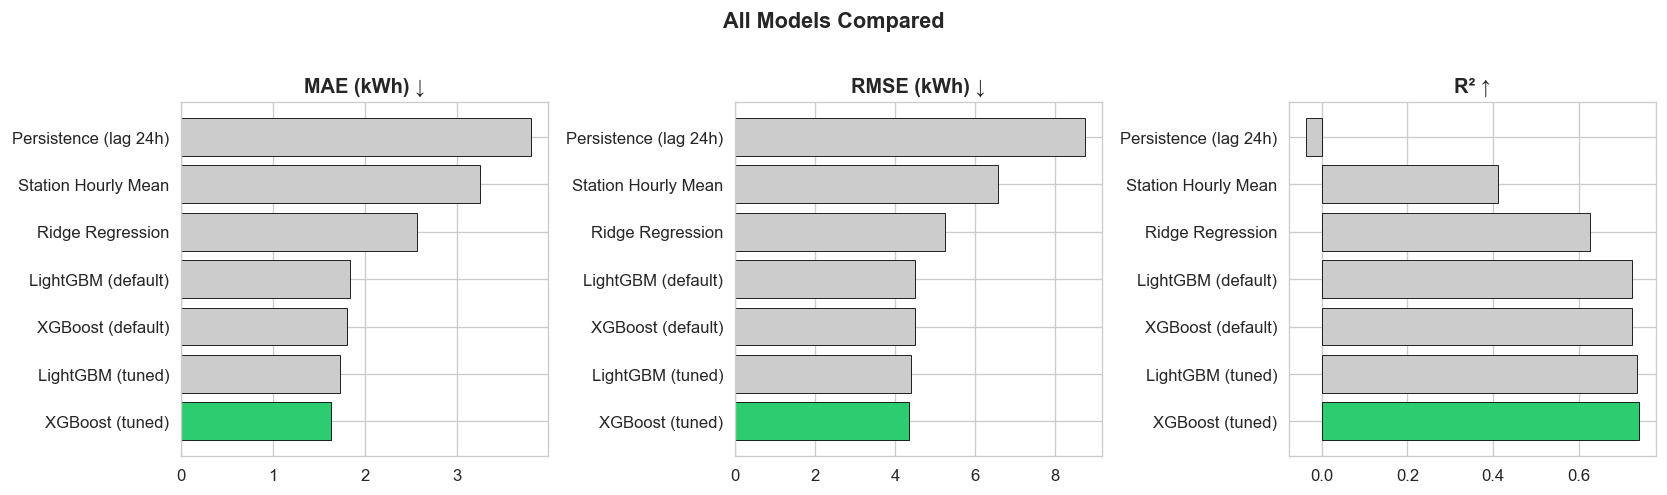

In [3]:
# Load the full comparison table saved by notebook 06
comparison = pd.read_csv(RESULTS_DIR / 'model_comparison.csv')
print(comparison.to_string(index=False))

# --- Bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['#cccccc'] * len(comparison)
colors[-1] = '#2ecc71'  # highlight best model (last row)

for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R²'], ['MAE (kWh) ↓', 'RMSE (kWh) ↓', 'R² ↑']):
    bars = ax.barh(comparison['Model'], comparison[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('All Models Compared', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Importance

Top 15 features by the best model's internal importance score (gain-based for XGBoost).

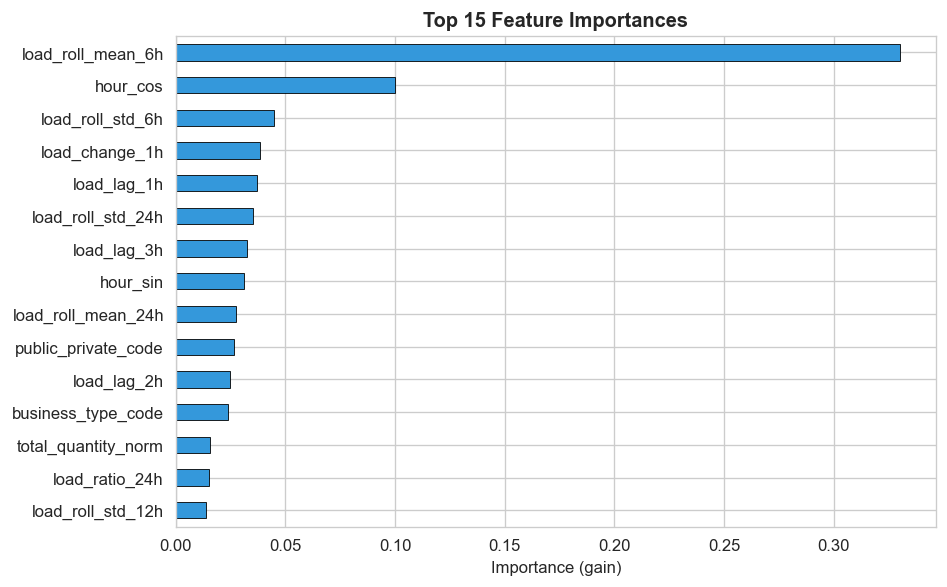


Top 15 features:
   1. load_roll_mean_6h            0.3301  (33.0%)
   2. hour_cos                     0.1001  (10.0%)
   3. load_roll_std_6h             0.0449  (4.5%)
   4. load_change_1h               0.0384  (3.8%)
   5. load_lag_1h                  0.0369  (3.7%)
   6. load_roll_std_24h            0.0351  (3.5%)
   7. load_lag_3h                  0.0327  (3.3%)
   8. hour_sin                     0.0312  (3.1%)
   9. load_roll_mean_24h           0.0276  (2.8%)
  10. public_private_code          0.0266  (2.7%)
  11. load_lag_2h                  0.0247  (2.5%)
  12. business_type_code           0.0240  (2.4%)
  13. total_quantity_norm          0.0156  (1.6%)
  14. load_ratio_24h               0.0150  (1.5%)
  15. load_roll_std_12h            0.0138  (1.4%)


In [4]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot.barh(ax=ax, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
for i, (feat, imp) in enumerate(top15.items(), 1):
    print(f'  {i:2d}. {feat:<28s} {imp:.4f}  ({imp/importances.sum()*100:.1f}%)')

## 4. Actual vs Predicted

Scatter plot of true load vs predicted load on the test set. Perfect predictions fall on the diagonal.

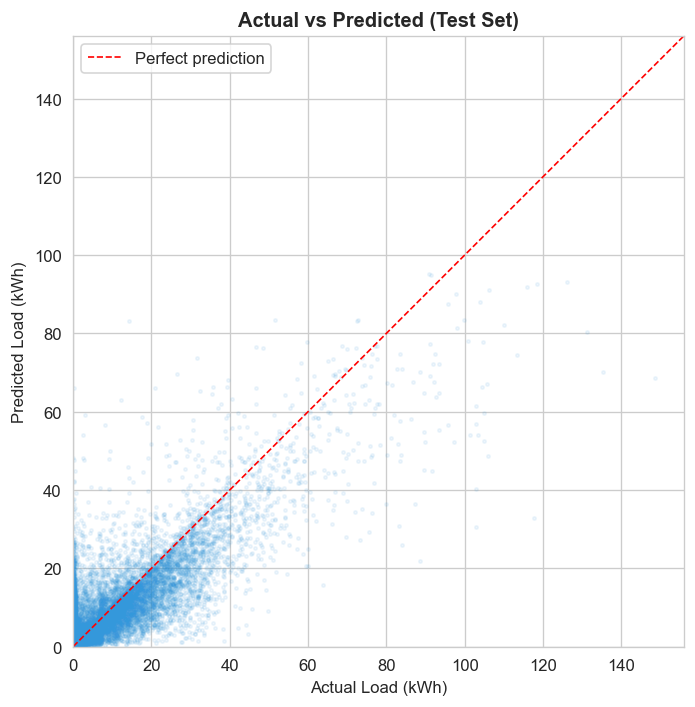

In [5]:
# Subsample for plotting (full test set is too dense)
np.random.seed(42)
idx = np.random.choice(len(y_test), size=min(50_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values[idx], y_pred_test[idx], alpha=0.08, s=4, color='#3498db')

# Diagonal reference line
lim = max(y_test.values[idx].max(), y_pred_test[idx].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')

ax.set_xlabel('Actual Load (kWh)')
ax.set_ylabel('Predicted Load (kWh)')
ax.set_title('Actual vs Predicted (Test Set)', fontweight='bold')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Residual Distribution

A well-behaved model should have residuals (actual - predicted) centered around zero with a roughly symmetric shape.

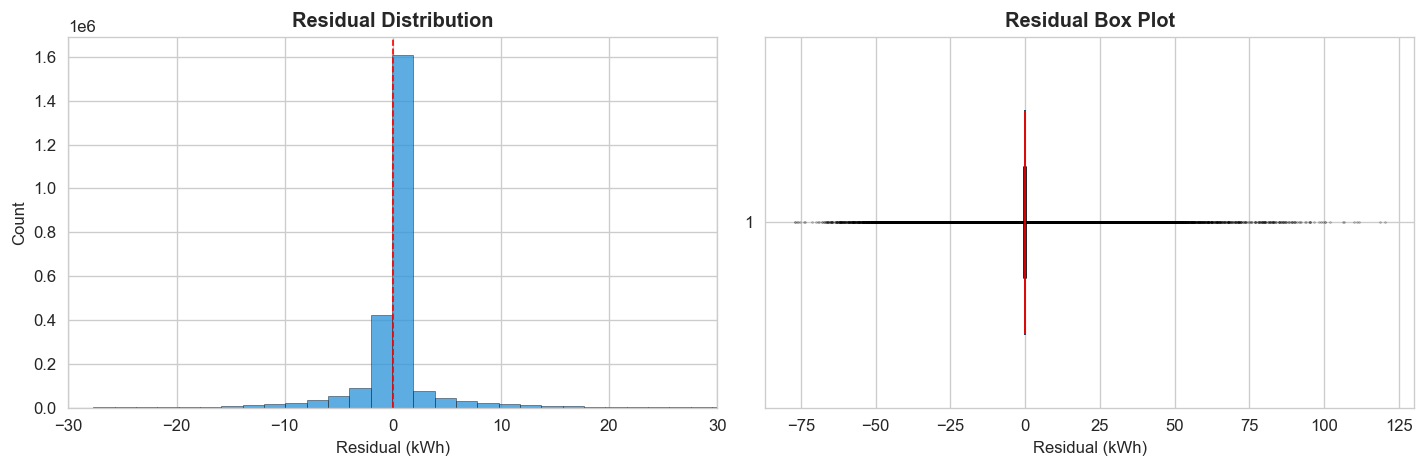

Mean residual:   -0.0201 kWh
Median residual: -0.0053 kWh
Std residual:    4.356 kWh
Skewness:        0.830


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(residuals, bins=100, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Residual (kWh)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlim(-30, 30)

# Box plot
axes[1].boxplot(residuals, vert=False, widths=0.6,
                boxprops=dict(color='#2c3e50'), medianprops=dict(color='red'),
                flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_title('Residual Box Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Mean residual:   {residuals.mean():.4f} kWh')
print(f'Median residual: {residuals.median():.4f} kWh')
print(f'Std residual:    {residuals.std():.3f} kWh')
print(f'Skewness:        {residuals.skew():.3f}')

## 6. Error by Hour of Day

Does the model struggle more at certain times? We expect higher errors during peak charging hours when load variance is highest.

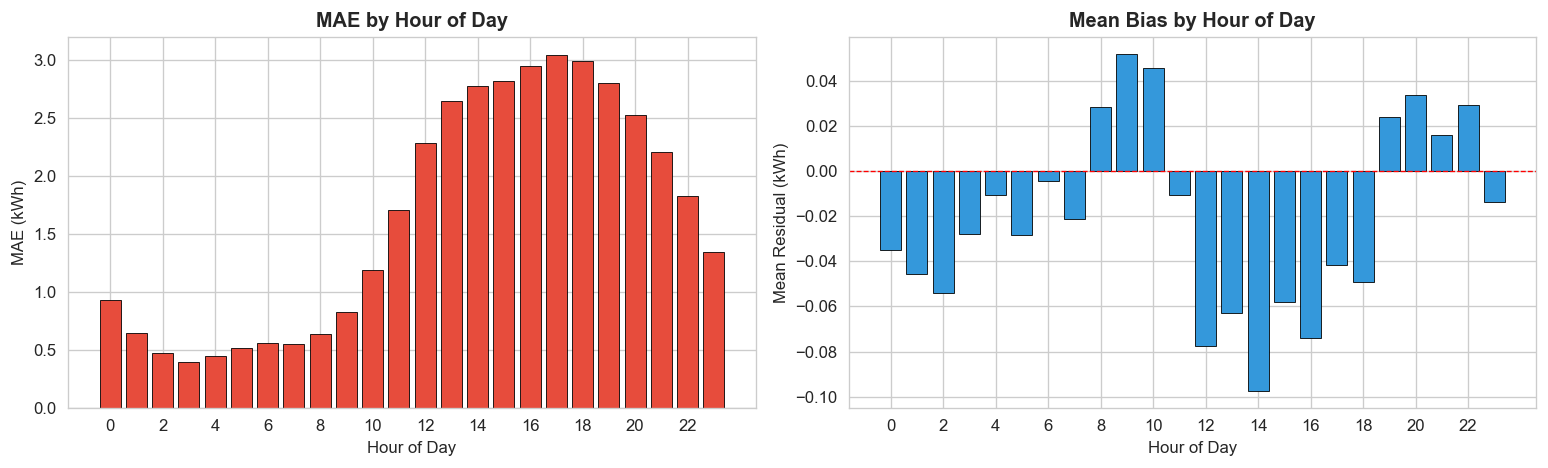

In [7]:
# Recover hour from cyclical encoding: atan2(sin, cos) → hour
hour_approx = np.round(np.arctan2(test['hour_sin'], test['hour_cos']) * 12 / np.pi) % 24
hour_approx = hour_approx.astype(int)

error_by_hour = pd.DataFrame({
    'hour': hour_approx.values,
    'abs_error': np.abs(residuals.values),
    'residual': residuals.values
}).groupby('hour').agg(
    MAE=('abs_error', 'mean'),
    mean_residual=('residual', 'mean'),
    count=('abs_error', 'size')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(error_by_hour.index, error_by_hour['MAE'], color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('MAE (kWh)')
axes[0].set_title('MAE by Hour of Day', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))

axes[1].bar(error_by_hour.index, error_by_hour['mean_residual'], color='#3498db', edgecolor='black', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Residual (kWh)')
axes[1].set_title('Mean Bias by Hour of Day', fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 7. Error by Day of Week

Checking if weekday/weekend patterns affect model accuracy.

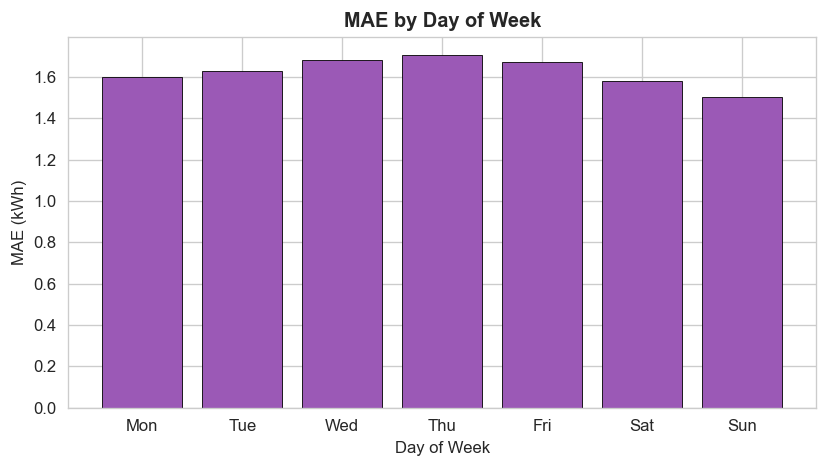

In [8]:
# Recover day of week from cyclical encoding
dow_approx = np.round(np.arctan2(test['dow_sin'], test['dow_cos']) * 3.5 / np.pi) % 7
dow_approx = dow_approx.astype(int)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

error_by_dow = pd.DataFrame({
    'dow': dow_approx.values,
    'abs_error': np.abs(residuals.values)
}).groupby('dow')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(7), error_by_dow.values, color='#9b59b6', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.set_xlabel('Day of Week')
ax.set_ylabel('MAE (kWh)')
ax.set_title('MAE by Day of Week', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Error by Load Magnitude

Binning actual load into ranges to see where the model is most/least accurate. Low-load hours are easy to predict (near zero), high-load hours have more variance.

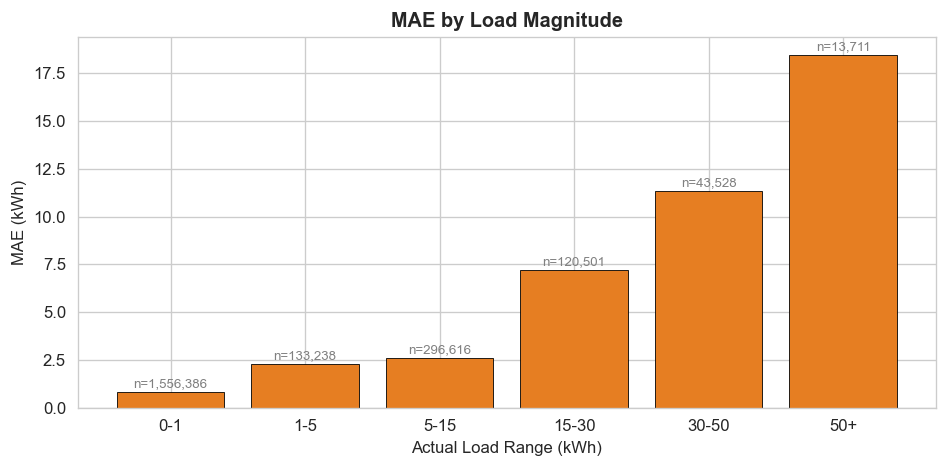

In [9]:
# Define load bins
bins = [0, 1, 5, 15, 30, 50, np.inf]
labels = ['0-1', '1-5', '5-15', '15-30', '30-50', '50+']

error_by_load = pd.DataFrame({
    'load_bin': pd.cut(y_test, bins=bins, labels=labels),
    'abs_error': np.abs(residuals.values)
})

agg = error_by_load.groupby('load_bin', observed=False).agg(
    MAE=('abs_error', 'mean'),
    count=('abs_error', 'size')
)

fig, ax1 = plt.subplots(figsize=(8, 4))
bars = ax1.bar(range(len(agg)), agg['MAE'], color='#e67e22', edgecolor='black', linewidth=0.5)
ax1.set_xticks(range(len(agg)))
ax1.set_xticklabels(labels)
ax1.set_xlabel('Actual Load Range (kWh)')
ax1.set_ylabel('MAE (kWh)')
ax1.set_title('MAE by Load Magnitude', fontweight='bold')

# Add count labels on bars
for i, (mae, count) in enumerate(zip(agg['MAE'], agg['count'])):
    ax1.text(i, mae + 0.1, f'n={count:,}', ha='center', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## 9. Per-Station Error

Distribution of MAE across all 585 stations. Some stations are inherently harder to predict (irregular usage patterns, rare usage, etc.).

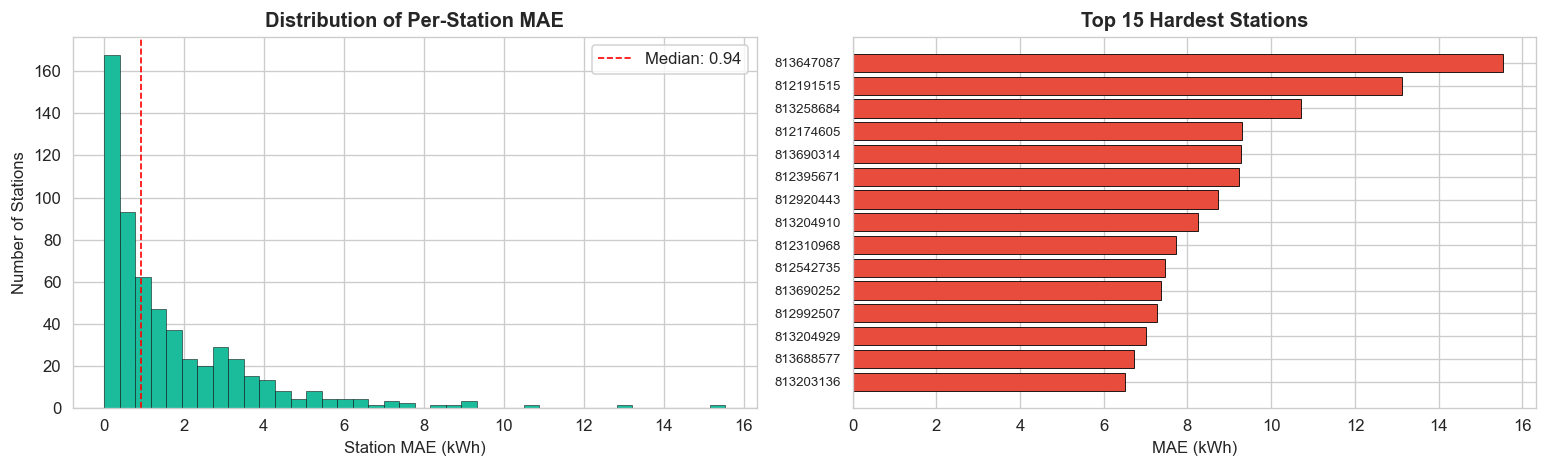

Stations in test set: 576
Median station MAE:   0.937 kWh
Best station MAE:     0.005 kWh
Worst station MAE:    15.547 kWh


In [10]:
station_errors = pd.DataFrame({
    'station': test['customer_id'].values,
    'abs_error': np.abs(residuals.values)
}).groupby('station')['abs_error'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of per-station MAE
axes[0].hist(station_errors, bins=40, color='#1abc9c', edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Station MAE (kWh)')
axes[0].set_ylabel('Number of Stations')
axes[0].set_title('Distribution of Per-Station MAE', fontweight='bold')
axes[0].axvline(station_errors.median(), color='red', linestyle='--', linewidth=1, label=f'Median: {station_errors.median():.2f}')
axes[0].legend()

# Top 15 hardest stations
top15_stations = station_errors.head(15)
axes[1].barh(range(15), top15_stations.values, color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([str(s)[:15] for s in top15_stations.index], fontsize=8)
axes[1].set_xlabel('MAE (kWh)')
axes[1].set_title('Top 15 Hardest Stations', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f'Stations in test set: {len(station_errors)}')
print(f'Median station MAE:   {station_errors.median():.3f} kWh')
print(f'Best station MAE:     {station_errors.min():.3f} kWh')
print(f'Worst station MAE:    {station_errors.max():.3f} kWh')

## 10. Worst Predictions

Looking at the 20 largest absolute errors to understand what kinds of situations the model struggles with most.

In [11]:
worst = pd.DataFrame({
    'station': test['customer_id'].values,
    'timestamp': test['timestamp_hour'].values,
    'actual': y_test.values,
    'predicted': y_pred_test,
    'error': residuals.values,
    'abs_error': np.abs(residuals.values),
    'hour': hour_approx.values,
    'is_weekend': test['is_weekend'].values
}).nlargest(20, 'abs_error')

print('Top 20 Worst Predictions:')
print(worst[['station', 'timestamp', 'actual', 'predicted', 'error', 'hour', 'is_weekend']].to_string(index=False))

Top 20 Worst Predictions:
  station           timestamp     actual  predicted      error  hour  is_weekend
813647087 2022-09-14 13:00:00 161.412702  41.111507 120.301195    13       False
813647087 2022-07-27 20:00:00 157.970001  39.189411 118.780590    20       False
813647087 2022-08-14 17:00:00 161.412702  49.551983 111.860719    17        True
813647087 2022-08-07 15:00:00 160.080002  49.086529 110.993473    15        True
813647087 2022-09-25 17:00:00 138.990005  29.098001 109.892004    17        True
813647087 2022-10-09 14:00:00 161.412702  54.636921 106.775781    14        True
813647087 2022-07-11 20:00:00 147.479996  41.017780 106.462215    20       False
813647087 2022-12-25 14:00:00 161.412702  59.403137 102.009565    14        True
813647087 2022-08-06 14:00:00 154.160004  53.764992 100.395012    14        True
813647087 2022-11-20 15:00:00 161.412702  61.154190 100.258512    15        True
813647087 2022-10-26 15:00:00 161.412702  61.887699  99.525003    15       False
81

## Key Takeaways

**Model performance:**
- XGBoost (tuned) is the best model with MAE = 1.68 kWh, R² = 0.827
- No overfitting detected (train/test R² gap = 0.016)
- Clear improvement from baselines (persistence R² = 0.31) to tuned gradient boosting (R² = 0.83)

**Error patterns:**
- Lag features (especially `load_lag_1h`, `load_lag_24h`) and rolling statistics dominate feature importance — the best predictor of future load is recent load
- Errors are largest during high-demand hours and at high-load stations — this is expected since these have the most variance
- The model slightly underpredicts extreme peaks (positive skew in residuals) — a common trait of tree-based models which predict toward the mean
- Most stations have low MAE; a small tail of high-traffic stations drives the overall error